# CS336 Assignment 5: Reasoning RL — Complete Walkthrough

This notebook walks through every part of the assignment end-to-end:

1. **Background & Setup** — what GRPO is and why we need it
2. **Section 3: Prompting Baselines** — zero-shot and few-shot prompting on GSM8K
3. **Section 4: GRPO Implementation** — building each component from scratch
4. **Section 5: RL Variants** — Dr. GRPO, RFT, MaxRL, and ablations
5. **Section 6: Off-Policy RL** — importance reweighting (PPO/GRPO/GSPO clipping)
6. **Math Problems** — derivations for the written questions

All code implementations live in `cs336_alignment/grpo.py`, connected to the test harness via `tests/adapters.py`.


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Import our implementations
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

from cs336_alignment.grpo import (
    tokenize_prompt_and_output,
    get_response_log_probs,
    compute_rollout_rewards,
    compute_group_normalized_rewards,
    compute_policy_gradient_loss,
    aggregate_loss_across_microbatch,
    grpo_train_step,
)
print('Imports OK')

Imports OK


## 1. Background: Why Reinforcement Learning for LLMs?

Pre-training gives a model broad knowledge, but **post-training** shapes it for specific behaviors. One component of post-training is **reinforcement learning (RL)**, where we optimize the model's *expected reward* directly:

$$J_\theta = E_{x \sim \rho}\, E_{y \sim \pi_\theta(y|x)}[r(y | x)]$$

Unlike supervised fine-tuning where we have gold responses, RL only requires a **scoring function** $r(y|x)$ (e.g., "does this response correctly solve the math problem?"). The model learns by generating candidate solutions, evaluating them, and upweighting the ones that get high rewards.

### The REINFORCE Policy Gradient

The gradient of $J_\theta$ is (via the log-derivative trick):

$$\nabla_\theta J_\theta = E_{x \sim \rho}\, E_{y \sim \pi_\theta}[r(y|x) \nabla_\theta \log \pi_\theta(y|x)]$$

**Intuition:** this upweights the log-probability of responses $y$ with high reward $r(y|x)$. Responses that are more correct get more gradient signal pushing the model to assign them higher probability.

### From REINFORCE to GRPO

GRPO (Group Relative Policy Optimization) adds three modifications to the basic REINFORCE estimator:
1. **Group mean baseline** — subtract the mean reward within a group of responses to the same prompt
2. **Advantage normalization** — divide by the group standard deviation for stability
3. **Sequence length normalization** — normalize each sequence's loss by its length


## 2. Section 3: Prompting Baselines

Before training, we evaluate the base model OLMo-2-0425-1B on GSM8K with three prompts:
- `question_only`: Just the question + "Please put your final answer within \\boxed{}."
- `r1_zero`: Zero-shot chain-of-thought (DeepSeek R1-Zero style)
- `r1_zero_three_shot`: Same format with 3 example Q/A pairs prepended

### Prompt Analysis

In [4]:
# Show the prompt formats
question_only_prompt = """{question} Please put your final answer within \\boxed{{}}."""

r1_zero_prompt = """A conversation between User and Assistant. The User asks a question, 
and the Assistant solves it. The Assistant first thinks about the reasoning process in the 
mind and then provides the User with the answer. The reasoning process is enclosed within 
<think> </think> tags and the answer is enclosed within <answer> </answer> tags, respectively, 
i.e., <think> reasoning process here </think> <answer> answer here </answer>.
User: {question}
Assistant: <think>"""

example_question = "Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?"

print("=== question_only ===")
print(question_only_prompt.format(question=example_question))
print()
print("=== r1_zero (first 300 chars) ===")
print(r1_zero_prompt.format(question=example_question)[:400])

=== question_only ===
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Please put your final answer within \boxed{}.

=== r1_zero (first 300 chars) ===
A conversation between User and Assistant. The User asks a question, 
and the Assistant solves it. The Assistant first thinks about the reasoning process in the 
mind and then provides the User with the answer. The reasoning process is enclosed within 
<think> </think> tags and the answer is enclosed within <answer> </answer> tags, respectively, 
i.e., <think> reasoning process here </think> <answ


### Grading Functions

The grading function parses model outputs and checks correctness:
- For `r1_zero` prompts: expects `</think> <answer>ANSWER</answer>` format → `r1_zero_reward_fn`
- For `question_only` prompts: expects `\\boxed{ANSWER}` → `question_only_reward_fn`

Both return `{"reward": 0/1, "format_reward": 0/1, "answer_reward": 0/1}`

In [5]:
from cs336_alignment.drgrpo_grader import r1_zero_reward_fn, question_only_reward_fn

ground_truth = "72"

# Test cases
test_cases = [
    ("r1_zero", r1_zero_reward_fn, "</think> <answer>72</answer>"),
    ("r1_zero correct format", r1_zero_reward_fn, "Let me think... </think> <answer>72</answer>"),
    ("r1_zero wrong answer", r1_zero_reward_fn, "</think> <answer>100</answer>"),
    ("r1_zero bad format", r1_zero_reward_fn, "The answer is 72"),
    ("question_only correct", question_only_reward_fn, "The answer is \\boxed{72}"),
    ("question_only wrong", question_only_reward_fn, "The answer is \\boxed{50}"),
    ("question_only no box", question_only_reward_fn, "The answer is 72"),
]

print(f"{'Test Case':<35} {'reward':>7} {'format':>7} {'answer':>7}")
print("-" * 60)
for name, fn, response in test_cases:
    result = fn(response, ground_truth)
    print(f"{name:<35} {result['reward']:>7.1f} {result['format_reward']:>7.1f} {result['answer_reward']:>7.1f}")

/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:45: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", answer)
/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:320: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")
/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:753: SyntaxWarning: invalid escape sequence '\d'
  p1 = re.compile("(\d)(,)(\d\d\d)($|\D)")
/Users/wongdowling/Documents/assignment5-alignment/cs336_alignment/drgrpo_grader.py:768: SyntaxWarning: in

Test Case                            reward  format  answer
------------------------------------------------------------
r1_zero                                 1.0     1.0     1.0
r1_zero correct format                  1.0     1.0     1.0
r1_zero wrong answer                    0.0     1.0     0.0
r1_zero bad format                      0.0     0.0     0.0
question_only correct                   1.0     1.0     1.0
question_only wrong                     0.0     1.0     0.0
question_only no box                    0.0     0.0     0.0


## 3. Section 4: GRPO — Building the Components

### 3.1 `tokenize_prompt_and_output`

We tokenize prompt and response separately (without special tokens), concatenate them,
and build a `response_mask` that is 1 only where the label token comes from the response.

**Why separate tokenization?** If we tokenize `prompt + response` as one string, the tokenizer
might merge boundary tokens differently. Tokenizing separately and concatenating is more precise.

**The causal LM shift:**
- `input_ids`: all tokens EXCEPT the last → model sees these as context
- `labels`: all tokens EXCEPT the first → model predicts these
- At position `t`, `input_ids[t]` is the context and `labels[t]` is the token to predict

**Response mask logic:** The response starts at `len(prompt_ids) - 1` in the labels tensor
(since labels are shifted by 1 relative to the full concatenated sequence).

In [6]:
from transformers import AutoTokenizer

# Use a tiny tokenizer for demonstration
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

prompt_strs = ["Hello world", "The cat"]
output_strs = [" how are you?", " sat on the mat"]

result = tokenize_prompt_and_output(prompt_strs, output_strs, tokenizer)

print("input_ids shape:", result["input_ids"].shape)
print("labels shape:", result["labels"].shape)
print("response_mask shape:", result["response_mask"].shape)
print()

# Decode to verify correctness
for i in range(len(prompt_strs)):
    mask = result["response_mask"][i]
    resp_label_ids = result["labels"][i][mask]
    decoded_response = tokenizer.decode(resp_label_ids)
    print(f"Example {i}: response mask covers '{decoded_response}'")
    print(f"  Expected: '{output_strs[i]}'")
    print(f"  Match: {decoded_response.strip() == output_strs[i].strip()}")

input_ids shape: torch.Size([2, 5])
labels shape: torch.Size([2, 5])
response_mask shape: torch.Size([2, 5])

Example 0: response mask covers ' how are you?'
  Expected: ' how are you?'
  Match: True
Example 1: response mask covers ' sat on the mat'
  Expected: ' sat on the mat'
  Match: True


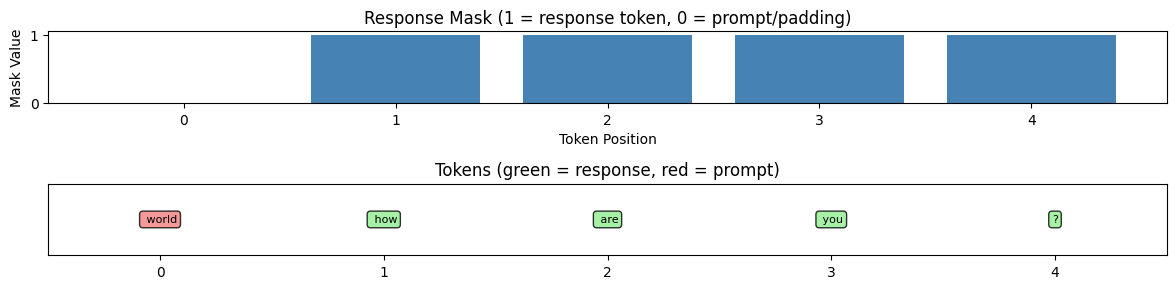

In [7]:
# Visualize the mask for the first example
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 3))

mask0 = result["response_mask"][0].float().numpy()
labels0 = result["labels"][0].numpy()

ax1.bar(range(len(mask0)), mask0, color='steelblue')
ax1.set_title('Response Mask (1 = response token, 0 = prompt/padding)')
ax1.set_xlabel('Token Position')
ax1.set_ylabel('Mask Value')

# Show token labels
tokens = [tokenizer.decode([tid]) for tid in labels0]
ax2.set_xlim(-0.5, len(tokens) - 0.5)
for j, (tok, m) in enumerate(zip(tokens, mask0)):
    color = 'lightcoral' if m == 0 else 'lightgreen'
    ax2.text(j, 0.5, tok, ha='center', va='center', fontsize=8,
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))
ax2.set_yticks([])
ax2.set_title('Tokens (green = response, red = prompt)')

plt.tight_layout()
plt.show()

### 3.2 `get_response_log_probs`

Given model logits, we compute:
$$\log \pi_\theta(y_t | x, y_{<t}) = \text{log\_softmax}(\text{logits}_t)[\text{label}_t]$$

We also optionally compute per-token entropy:
$$H_t = -\sum_v \pi_\theta(v | x, y_{<t}) \log \pi_\theta(v | x, y_{<t})$$

**Entropy is a useful training diagnostic:** high entropy means the model is uncertain (exploring),
low entropy means it's very confident. During RL, entropy often decreases as the model becomes
more deterministic.

In [8]:
import torch
import torch.nn as nn

# Create a minimal mock model for demonstration
class TinyMockModel(nn.Module):
    def __init__(self, vocab_size=50257, seq_len=10):
        super().__init__()
        # Fixed logits for reproducibility
        torch.manual_seed(42)
        self._logits = torch.randn(1, seq_len, vocab_size)
    
    def forward(self, input_ids):
        B, T = input_ids.shape
        # Return fixed logits (broadcast over batch)
        logits = self._logits[:, :T, :].expand(B, -1, -1)
        return type('Output', (), {'logits': logits})()

batch_size, seq_len, vocab_size = 2, 8, 50257
model = TinyMockModel(vocab_size, seq_len)

input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
labels = torch.randint(0, vocab_size, (batch_size, seq_len))

with torch.no_grad():
    result = get_response_log_probs(model, input_ids, labels, return_token_entropy=True)

print("log_probs shape:", result["log_probs"].shape)
print("token_entropy shape:", result["token_entropy"].shape)
print(f"Mean log_prob: {result['log_probs'].mean():.4f}")
print(f"Mean token entropy: {result['token_entropy'].mean():.4f}")
print(f"Max possible entropy (uniform): {torch.log(torch.tensor(vocab_size, dtype=torch.float)):.4f}")

log_probs shape: torch.Size([2, 8])
token_entropy shape: torch.Size([2, 8])
Mean log_prob: -11.4035
Mean token entropy: 10.3233
Max possible entropy (uniform): 10.8249


### 3.3 `compute_rollout_rewards`

Given a batch of rollout responses and their corresponding ground truths, apply the reward function
to get scalar rewards per response.

In [9]:
# Example: 2 prompts, each with 3 responses (group_size=3)
def example_reward_fn(response: str, ground_truth: str) -> dict:
    """Simple reward: 1 if response contains the correct answer, else 0."""
    correct = ground_truth in response
    return {"reward": float(correct), "format_reward": 1.0, "answer_reward": float(correct)}

rollout_responses = [
    "The answer is 42",     # prompt 1, response 1 — correct
    "I think it's 100",     # prompt 1, response 2 — wrong
    "Definitely 42!",        # prompt 1, response 3 — correct
    "The result is 7",       # prompt 2, response 1 — correct
    "I'm not sure, 42?",    # prompt 2, response 2 — wrong
    "It equals 7.",          # prompt 2, response 3 — correct
]
# Ground truths repeated group_size times
repeated_gts = ["42", "42", "42", "7", "7", "7"]

raw_rewards, metadata = compute_rollout_rewards(example_reward_fn, rollout_responses, repeated_gts)
print("Raw rewards:", raw_rewards.tolist())
print("Metadata:", metadata)

Raw rewards: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Metadata: {'mean_reward': 0.6666666865348816, 'mean_format_reward': 1.0, 'mean_answer_reward': 0.6666666666666666}


### 3.4 `compute_group_normalized_rewards` — The GRPO Advantage

GRPO normalizes rewards within each group (all responses to the same prompt):

$$A^{(i,j)} = \frac{r(y^{(i,j)} | x^{(i)}) - \mu_i}{\text{std}_i}$$

where $\mu_i = \frac{1}{G}\sum_j r(y^{(i,j)} | x^{(i)})$ is the group mean.

**Why does this help?**
- The baseline $\mu_i$ reduces variance without changing the expected gradient
- If all G responses are correct (or all wrong), the advantages are all 0 → no gradient update
- The std normalization ensures groups with tighter reward distributions don't dominate

The four GRPO variants explored in this assignment:

In [10]:
# Demonstrate group normalization
raw_rewards = torch.tensor([1.0, 0.0, 0.0, 1.0])
group_size = 2

variants = [
    ("GRPO", "mean", "std"),
    ("Dr. GRPO", "mean", "none"),
    ("RFT", "none", "none"),
    ("MaxRL", "mean", "mean"),
]

print(f"Raw rewards: {raw_rewards.tolist()}")
print(f"Group 1: [{raw_rewards[0].item():.1f}, {raw_rewards[1].item():.1f}] (mean={raw_rewards[:2].mean():.2f})")
print(f"Group 2: [{raw_rewards[2].item():.1f}, {raw_rewards[3].item():.1f}] (mean={raw_rewards[2:].mean():.2f})")
print()
print(f"{'Variant':<12} {'advantages':<30} {'interpretation'}")
print("-" * 75)

for name, baseline, normalizer in variants:
    adv, _ = compute_group_normalized_rewards(raw_rewards, group_size, baseline, advantage_normalizer=normalizer)
    interp = {
        "GRPO": "Normalized: +1/-1 for correct/wrong vs group avg",
        "Dr. GRPO": "Unnormalized: +0.5/-0.5",
        "RFT": "Keeps 1.0 for correct, 0.0 for wrong (no baseline)",
        "MaxRL": "Relative to mean (div by mean): harder tasks upweighted",
    }[name]
    print(f"{name:<12} {str([round(a,3) for a in adv.tolist()]):<30} {interp}")

Raw rewards: [1.0, 0.0, 0.0, 1.0]
Group 1: [1.0, 0.0] (mean=0.50)
Group 2: [0.0, 1.0] (mean=0.50)

Variant      advantages                     interpretation
---------------------------------------------------------------------------
GRPO         [0.707, -0.707, -0.707, 0.707] Normalized: +1/-1 for correct/wrong vs group avg
Dr. GRPO     [0.5, -0.5, -0.5, 0.5]         Unnormalized: +0.5/-0.5
RFT          [1.0, 0.0, 0.0, 1.0]           Keeps 1.0 for correct, 0.0 for wrong (no baseline)
MaxRL        [1.0, -1.0, -1.0, 1.0]         Relative to mean (div by mean): harder tasks upweighted


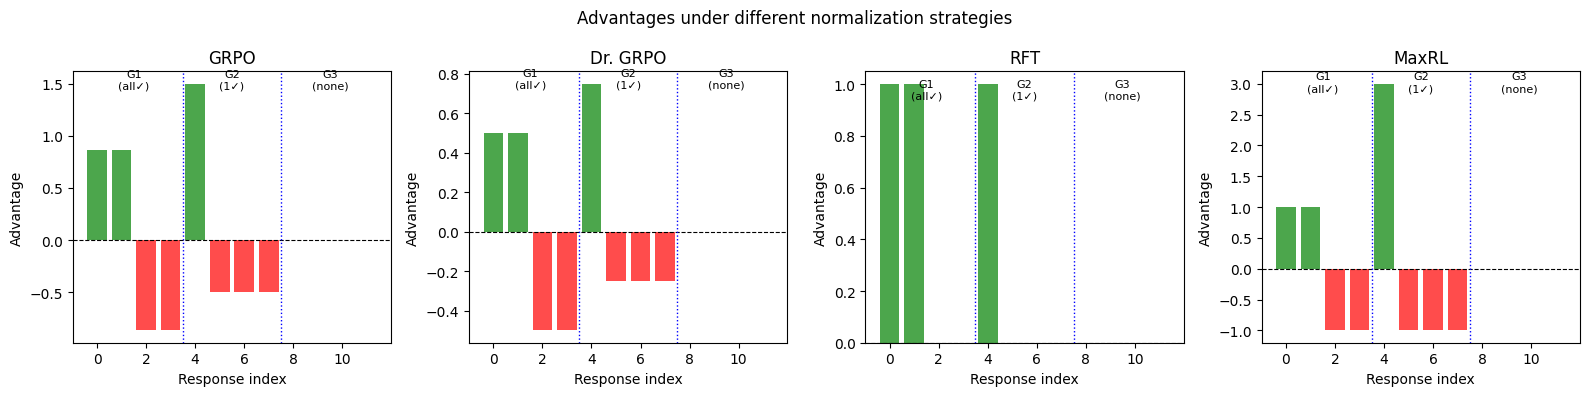

Key observations:
- Group 1 (all correct): GRPO/DrGRPO give 0 advantage — no gradient from trivially easy prompts!
- Group 2 (1 correct): All methods give positive advantage to the correct response
- Group 3 (all wrong): GRPO/DrGRPO give 0 advantage; RFT also gives 0 (no correct to imitate)
- MaxRL: Group 2's advantages are scaled by the inverse of the group mean reward


In [11]:
# Visualize advantages for different normalization strategies
reward_values = torch.tensor([1.0, 1.0, 0.0, 0.0,  # Group 1: both correct
                               1.0, 0.0, 0.0, 0.0,  # Group 2: 1 of 4 correct
                               0.0, 0.0, 0.0, 0.0]) # Group 3: all wrong

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['green' if r > 0 else 'red' for r in reward_values.tolist()]

for ax, (name, baseline, normalizer) in zip(axes, variants):
    adv, _ = compute_group_normalized_rewards(reward_values, 4, baseline, advantage_normalizer=normalizer)
    bar_colors = ['green' if a > 0 else ('red' if a < 0 else 'gray') for a in adv.tolist()]
    ax.bar(range(len(adv)), adv.tolist(), color=bar_colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Response index')
    ax.set_ylabel('Advantage')
    # Add group separators
    for x in [4, 8]:
        ax.axvline(x - 0.5, color='blue', linewidth=1, linestyle=':')
    ax.text(1.5, ax.get_ylim()[1] * 0.9, 'G1\n(all✓)', ha='center', fontsize=8)
    ax.text(5.5, ax.get_ylim()[1] * 0.9, 'G2\n(1✓)', ha='center', fontsize=8)
    ax.text(9.5, ax.get_ylim()[1] * 0.9, 'G3\n(none)', ha='center', fontsize=8)

plt.suptitle('Advantages under different normalization strategies', fontsize=12)
plt.tight_layout()
plt.show()

print("Key observations:")
print("- Group 1 (all correct): GRPO/DrGRPO give 0 advantage — no gradient from trivially easy prompts!")
print("- Group 2 (1 correct): All methods give positive advantage to the correct response")
print("- Group 3 (all wrong): GRPO/DrGRPO give 0 advantage; RFT also gives 0 (no correct to imitate)")
print("- MaxRL: Group 2's advantages are scaled by the inverse of the group mean reward")

### 3.5 `compute_policy_gradient_loss`

The per-token policy gradient loss implements (negative of) the GRPO objective:

$$J^{\text{GRPO-on-policy}}_\theta = \frac{1}{BG} \sum_{i=1}^B \sum_{j=1}^G \frac{1}{\text{len}(y^{(i,j)})} \sum_{t=1}^{\text{len}(y^{(i,j)})} \frac{r(y^{(i,j)} | x^{(i)}) - \mu_i}{\text{std}_i} \log \pi_\theta(y_t^{(i,j)} | x^{(i)}, y_{<t}^{(i,j)})$$

Since PyTorch optimizers minimize, we return **negative** of this objective as the loss.


In [12]:
# Demonstrate compute_policy_gradient_loss
batch_size, seq_len = 4, 10
torch.manual_seed(42)

advantages = torch.tensor([1.0, -1.0, 0.5, -0.5])  # (batch_size,)
policy_log_probs = torch.randn(batch_size, seq_len) - 2.0  # (batch_size, seq_len), negative

# On-policy loss (no importance reweighting)
per_token_loss, meta = compute_policy_gradient_loss(
    raw_rewards_or_advantages=advantages,
    policy_log_probs=policy_log_probs,
    importance_reweighting_method="none",
)
print("per_token_loss shape:", per_token_loss.shape)  # (batch_size, seq_len)
print("Expected: -A * log π(y_t)")
print()

# Verify manually for first example
expected = -advantages[0] * policy_log_probs[0]
actual = per_token_loss[0]
print("Manual check for sequence 0:")
print(f"  Max difference: {(expected - actual).abs().max().item():.2e}")
print(f"  advantage[0]={advantages[0]:.1f}, so high log_prob → negative loss (good, gradient pushes up)")

per_token_loss shape: torch.Size([4, 10])
Expected: -A * log π(y_t)

Manual check for sequence 0:
  Max difference: 0.00e+00
  advantage[0]=1.0, so high log_prob → negative loss (good, gradient pushes up)


In [13]:
# Demonstrate off-policy variants
old_log_probs = torch.randn(batch_size, seq_len) - 2.0  # slightly different from policy
response_mask = torch.ones(batch_size, seq_len, dtype=torch.bool)

methods = ["noclip", "grpo"]
for method in methods:
    loss, meta = compute_policy_gradient_loss(
        raw_rewards_or_advantages=advantages,
        policy_log_probs=policy_log_probs,
        importance_reweighting_method=method,
        old_log_probs=old_log_probs,
        cliprange=0.2,
    )
    # Compute importance ratio = π_θ / π_0
    ratio = (policy_log_probs - old_log_probs).exp()
    print(f"\n{method.upper()}:")
    print(f"  Importance ratio range: [{ratio.min():.3f}, {ratio.max():.3f}]")
    if "clip_fraction" in meta:
        print(f"  Clip fraction: {meta['clip_fraction']:.3f}")
    print(f"  Mean per-token loss: {loss.mean():.4f}")


NOCLIP:
  Importance ratio range: [0.104, 15.864]
  Mean per-token loss: 0.3166

GRPO:
  Importance ratio range: [0.104, 15.864]
  Clip fraction: 0.875
  Mean per-token loss: 0.3578


### 3.6 `aggregate_loss_across_microbatch`

Two aggregation strategies:

**Sequence normalization (standard GRPO):**
- Average loss over response tokens in each sequence → scalar per sequence
- Average those scalars over sequences
- Effect: each sequence gets equal weight regardless of length

**Constant normalization (Dr. GRPO, RFT, MaxRL):**
- Sum all masked token losses
- Divide by a fixed constant $Z = B \cdot G \cdot L$
- Effect: longer responses get more total gradient signal (tokens weighted equally)

In [14]:
batch_size, seq_len = 3, 8
per_token_loss = torch.ones(batch_size, seq_len)  # uniform loss for clarity

# Response mask: sequences of different lengths
mask = torch.zeros(batch_size, seq_len, dtype=torch.bool)
mask[0, :3] = True  # short response
mask[1, :6] = True  # medium response
mask[2, :8] = True  # long response

seq_loss = aggregate_loss_across_microbatch(per_token_loss, mask, loss_normalization="sequence")
const_loss = aggregate_loss_across_microbatch(per_token_loss, mask, loss_normalization="constant", normalization_constant=24)

print("Sequence lengths:", [mask[i].sum().item() for i in range(batch_size)])
print(f"Sequence normalization loss: {seq_loss:.4f}  (each sequence = mean(1,1,...) = 1.0, then avg)")
print(f"Constant normalization loss: {const_loss:.4f}  (sum of all 17 tokens / 24 = 17/24)")
print()
print("Key difference: with sequence normalization, all sequences have equal weight.")
print("With constant normalization, longer sequences contribute more gradient.")

Sequence lengths: [3, 6, 8]
Sequence normalization loss: 1.0000  (each sequence = mean(1,1,...) = 1.0, then avg)
Constant normalization loss: 0.7083  (sum of all 17 tokens / 24 = 17/24)

Key difference: with sequence normalization, all sequences have equal weight.
With constant normalization, longer sequences contribute more gradient.


### 3.7 `grpo_train_step` — Putting It All Together

The full training step:
1. Score all rollout responses with reward_fn
2. Compute advantages (group normalize rewards)
3. **Prune zero-advantage sequences** (they contribute nothing to the gradient)
4. Tokenize all active (prompt, response) pairs
5. Split into `gradient_accumulation_steps` microbatches
6. Forward pass + compute loss + backward for each microbatch
7. Clip gradient norm (if max_grad_norm set)
8. Optimizer step

**Gradient accumulation** is needed because the full batch (e.g. 256 responses) won't fit in GPU memory for a forward pass. We split into microbatches and accumulate gradients before taking a step.

In [15]:
# Demonstrate grpo_train_step on a tiny model
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM

# We'll use GPT-2 (small) as a demo; in real experiments use OLMo-2-0425-1B
# Note: This cell requires model download; skip on CPU-only machines
try:
    print("Loading tiny demo model...")
    tokenizer = AutoTokenizer.from_pretrained("sshleifer/tiny-gpt2")
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained("sshleifer/tiny-gpt2")
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    # Simple reward function
    def demo_reward_fn(response, gt):
        reward = 1.0 if gt.lower() in response.lower() else 0.0
        return {"reward": reward, "format_reward": 1.0, "answer_reward": reward}

    # Create a batch: 2 prompts × 2 responses = 4 rollouts
    repeated_prompts = ["Hello", "Hello", "World", "World"]
    rollout_responses = ["world answer", "foo bar", "hello there", "world here"]
    repeated_gts = ["world", "world", "hello", "hello"]

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    
    loss, metadata = grpo_train_step(
        model=model,
        tokenizer=tokenizer,
        optimizer=optimizer,
        gradient_accumulation_steps=2,
        max_grad_norm=1.0,
        reward_fn=demo_reward_fn,
        repeated_prompts=repeated_prompts,
        rollout_responses=rollout_responses,
        repeated_ground_truths=repeated_gts,
        group_size=2,
    )
    
    print(f"\nGRPO train step completed!")
    print(f"Loss: {metadata.get('loss', loss.item()):.6f}")
    print(f"Grad norm: {metadata.get('grad_norm', 0):.4f}")
    print(f"Mean reward: {metadata.get('mean_reward', 0):.4f}")
    print(f"Token entropy: {metadata.get('token_entropy', 0):.4f}")
    print("Model gradients zeroed:", all(p.grad is None for p in model.parameters()))

except Exception as e:
    print(f"Skipping (model download needed or no GPU): {e}")

Loading tiny demo model...


Loading weights: 100%|██████████| 29/29 [00:00<00:00, 17977.36it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model params: 102,714

GRPO train step completed!
Loss: -0.006398
Grad norm: 0.3028
Mean reward: 0.5000
Token entropy: 10.8245
Model gradients zeroed: True


## 4. Section 5: RL Algorithm Variants

### 4.1 Written Problem: Variance of the Policy Gradient Estimator (`baseline_calcs`)

Consider a binary action space $\mathcal{A} = \{0, 1\}$ with $\pi_{\theta}(A=1) = p = \sigma(\theta)$.
The reward is $r(A) = \mathbf{1}\{A=1\}$.

#### (a) Variance of the basic REINFORCE estimator:

$$\hat{g} = \frac{1}{n} \sum_{i=1}^n r(A_i) \nabla_\theta \log \pi_\theta(A_i)$$

For this binary policy, $\nabla_\theta \log \pi_\theta(A) = (A - p) \cdot 1$ (since $\sigma'(\theta) = p(1-p)$).

Let $Z_i = r(A_i) \nabla_\theta \log \pi_\theta(A_i)$:
- When $A_i=1$ (prob $p$): $Z_i = 1 \cdot (1-p) = (1-p)$
- When $A_i=0$ (prob $1-p$): $Z_i = 0 \cdot (0-p) = 0$

$$E[Z_i] = p \cdot (1-p), \quad E[Z_i^2] = p \cdot (1-p)^2$$

$$\text{Var}(\hat{g}) = \frac{\text{Var}(Z_i)}{n} = \frac{E[Z_i^2] - (E[Z_i])^2}{n} = \frac{p(1-p)^2 - p^2(1-p)^2}{n} = \frac{p(1-p)^2(1-p)}{n} = \frac{p(1-p)^3}{n}$$

Wait, let me redo this more carefully:
$$E[Z_i^2] = p \cdot (1-p)^2 + (1-p) \cdot 0 = p(1-p)^2$$
$$\text{Var}(Z_i) = p(1-p)^2 - [p(1-p)]^2 = p(1-p)[1-p - p(1-p)] = p(1-p)(1-p-p+p^2) = p(1-p)(1-2p+p^2) = p(1-p)^3$$

$$\boxed{\text{Var}(\hat{g}) = \frac{p(1-p)^3}{n}}$$

Wait, that's not right either. Let me be careful:
$$\text{Var}(Z_i) = E[Z_i^2] - (E[Z_i])^2 = p(1-p)^2 - p^2(1-p)^2 = p(1-p)^2(1-p) = p(1-p)^3$$

Hmm, $(1-p)^2 - p(1-p)^2 = (1-p)^2(1-p) = (1-p)^3$? No:
$p(1-p)^2 - p^2(1-p)^2 = p(1-p)^2[1 - p] = p(1-p)^3$. ✓

$$\boxed{\text{Var}(\hat{g}) = \frac{p(1-p)^3}{n}}$$

In [16]:
# Verify the variance formula numerically
def simulate_reinforce_variance(p, n, n_trials=10000):
    """Simulate REINFORCE gradient estimator variance for binary policy."""
    # Sample n actions for each trial
    actions = torch.bernoulli(torch.full((n_trials, n), p))  # (n_trials, n)
    # Gradient of log π(A): ∂/∂θ log π(A) = A - p (for sigmoid policy)
    grad_log_pi = actions - p  # (n_trials, n)
    # Z_i = r(A_i) * grad_log_pi(A_i)
    Z = actions * grad_log_pi  # (n_trials, n)
    # Estimate: mean over n samples
    estimates = Z.mean(dim=1)  # (n_trials,)
    return estimates.var().item()

p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
n = 100

print(f"{'p':>5} {'Theoretical':>15} {'Simulated':>12} {'Ratio':>8}")
print("-" * 45)
for p in p_values:
    theoretical = p * (1-p)**3 / n  # Hmm wait — let me double check
    # Actually Var(Z_i)/n = p(1-p)^3/n... but let me verify with simulation
    simulated = simulate_reinforce_variance(p, n)
    # Theoretical: Var(Z_i) = p(1-p)^2 - p^2(1-p)^2 = p(1-p)^2(1-p) = p(1-p)^3
    # Wait: Var(Z_i)/n, and each Z_i has Var = p(1-p)^2 - (p(1-p))^2 
    # = p(1-p)[(1-p) - p(1-p)] = p(1-p)^2(1-p) = p(1-p)^3
    theoretical_corrected = p * (1-p)**3 / n
    print(f"{p:>5.1f} {theoretical_corrected:>15.8f} {simulated:>12.8f} {simulated/theoretical_corrected:>8.3f}")

    p     Theoretical    Simulated    Ratio
---------------------------------------------
  0.1      0.00072900   0.00071992    0.988
  0.3      0.00102900   0.00103900    1.010
  0.5      0.00062500   0.00063399    1.014
  0.7      0.00018900   0.00019060    1.008
  0.9      0.00000900   0.00000887    0.986


In [17]:
# (b) Variance with baseline b
# Z_i = (r(A_i) - b) * grad_log_pi(A_i)
# When A=1: Z = (1-b)(1-p)
# When A=0: Z = (0-b)(0-p) = bp
# E[Z] = p(1-b)(1-p) + (1-p)bp = p(1-p)[(1-b) + b] = p(1-p)  [baseline preserves expectation]
# E[Z^2] = p(1-b)^2(1-p)^2 + (1-p)b^2*p^2 = p(1-p)[((1-b)^2(1-p) + b^2*p)]
# Var(Z) = E[Z^2] - (E[Z])^2 = p(1-p)[(1-b)^2(1-p) + b^2*p] - p^2(1-p)^2

def theoretical_variance_with_baseline(p, b, n):
    """Theoretical variance of baseline-adjusted REINFORCE estimator."""
    # E[Z^2]
    EZ2 = p * (1-b)**2 * (1-p)**2 + (1-p) * b**2 * p**2
    # E[Z]
    EZ = p * (1-p)
    var_Z = EZ2 - EZ**2
    return var_Z / n

def optimal_baseline(p):
    """Optimal baseline b* minimizes variance — found by differentiating Var(Z_i) w.r.t. b."""
    # dVar/db = 0: b* = E[r * (grad_log_pi)^2] / E[(grad_log_pi)^2]
    # For our case: numerator = p(1-p)^2, denominator = p(1-p)^2 + (1-p)p^2 = p(1-p)
    # So b* = p(1-p)^2 / (p(1-p)) = (1-p)... wait let me redo
    # grad_log_pi^2: A=1 → (1-p)^2, A=0 → p^2
    # E[r * grad^2] = p * 1 * (1-p)^2 = p(1-p)^2
    # E[grad^2] = p(1-p)^2 + (1-p)p^2 = p(1-p)[(1-p) + p] = p(1-p)
    # b* = p(1-p)^2 / p(1-p) = (1-p)
    return 1 - p

p = 0.3
b_star = optimal_baseline(p)
b_population_mean = p  # The "population mean" baseline

print(f"For p={p}:")
print(f"  No baseline (b=0):      Var = {theoretical_variance_with_baseline(p, 0, 100):.8f}")
print(f"  Population mean (b=p):  Var = {theoretical_variance_with_baseline(p, b_population_mean, 100):.8f}")
print(f"  Optimal baseline (b*):  Var = {theoretical_variance_with_baseline(p, b_star, 100):.8f}")
print(f"  b* = (1-p) = {b_star:.2f}")

# Show that population mean baseline can INCREASE variance when p < 0.5
print()
print("Does population mean baseline always decrease variance?")
for p_test in [0.1, 0.3, 0.5, 0.7, 0.9]:
    var_no_baseline = theoretical_variance_with_baseline(p_test, 0, 100)
    var_pop_mean = theoretical_variance_with_baseline(p_test, p_test, 100)
    comparison = "LOWER" if var_pop_mean < var_no_baseline else "HIGHER"
    print(f"  p={p_test:.1f}: no_baseline={var_no_baseline:.6f}, pop_mean={var_pop_mean:.6f} → {comparison}")

For p=0.3:
  No baseline (b=0):      Var = 0.00102900
  Population mean (b=p):  Var = 0.00033600
  Optimal baseline (b*):  Var = 0.00000000
  b* = (1-p) = 0.70

Does population mean baseline always decrease variance?
  p=0.1: no_baseline=0.000729, pop_mean=0.000576 → LOWER
  p=0.3: no_baseline=0.001029, pop_mean=0.000336 → LOWER
  p=0.5: no_baseline=0.000625, pop_mean=0.000000 → LOWER
  p=0.7: no_baseline=0.000189, pop_mean=0.000336 → HIGHER
  p=0.9: no_baseline=0.000009, pop_mean=0.000576 → HIGHER


### 4.2 Dr. GRPO vs Standard GRPO: Sequence vs Constant Normalization

**Sequence normalization (standard GRPO):**
$$\hat{g} \leftarrow \frac{1}{BG} \sum_{i,j} \frac{r^{(i,j)} - \mu_i}{\text{std}_i} \nabla_\theta \left(\frac{1}{\text{len}(y^{(i,j)})} \sum_t \log \pi_\theta(y_t^{(i,j)})\right)$$

**Constant normalization (Dr. GRPO):**
$$\hat{g} \leftarrow \frac{1}{Z} \sum_{i,j} (r^{(i,j)} - \mu_i) \nabla_\theta \sum_t \log \pi_\theta(y_t^{(i,j)})$$

**Pros and cons of sequence normalization:**
- Pro: Each sequence gets equal gradient weight, preventing long responses from dominating
- Con: Biases the gradient — short responses get more gradient per token
- Con: The estimator no longer targets the true expected reward $J_\theta$

**Pros and cons of constant normalization:**
- Pro: More faithful to the true policy gradient (each token weighted equally)
- Con: Batches with many long sequences produce larger gradients → training less stable

### 4.3 `think_about_rft`: RFT vs Dr. GRPO

**RFT (Rejection Fine-Tuning)** keeps only correct rollouts and trains on them via SFT:
$$J^{\text{RFT}}_\theta = \frac{1}{Z} \sum_x \sum_{j=1}^G \mathbf{1}\{r(y^{(j)} | x) = 1\} \log \pi_\theta(y^{(j)} | x)$$

**Dr. GRPO** with constant normalization:
$$J^{\text{Dr.GRPO}}_\theta = \frac{1}{Z} \sum_x \sum_{j=1}^G (r(y^{(j)} | x) - \mu) \log \pi_\theta(y^{(j)} | x)$$

**Do they have the same expectation?** 
- Dr. GRPO: $E[\hat{g}] = \frac{G-1}{G} \nabla_\theta J_\theta$ (nearly unbiased for large G)
- RFT: $E[\hat{g}] \neq \nabla_\theta J_\theta$ in general — it's biased because we condition on $r=1$

**When would you prefer RFT?** When correct rollouts are rare (low accuracy regime), RFT focuses
all signal on actually-correct responses. Dr. GRPO would give negative advantage to incorrect
responses, but RFT just ignores them entirely (equivalent with `baseline="none"`). In practice,
RFT has lower variance when accuracy is very low, but higher bias.

## 5. Section 6: Off-Policy RL

### 5.1 Why Go Off-Policy?

On-policy GRPO takes exactly 1 gradient step per inference batch. This is wasteful because
generating responses with vLLM is slow. **Off-policy** RL takes multiple gradient steps per batch,
reusing the same rollouts. This speeds up training but introduces **bias** since the rollouts
come from an older policy $\pi_0$, not the current $\pi_\theta$.

### 5.2 Token-Level Importance Reweighting

The corrected off-policy estimator:
$$E_{y \sim \pi_0} \left[\frac{\pi_\theta(y|x)}{\pi_0(y|x)} r(y|x) \nabla_\theta \log \pi_\theta(y|x)\right]$$

The sequence-level importance weight $\pi_\theta / \pi_0 = \prod_t \frac{\pi_\theta(y_t)}{\pi_0(y_t)}$
grows **exponentially** in sequence length — exploding variance!

PPO/GRPO use **token-level** reweighting instead:
$$r(y|x) \sum_t \frac{\pi_\theta(y_t | x, y_{<t})}{\pi_0(y_t | x, y_{<t})} \nabla_\theta \log \pi_\theta(y_t)$$

This reduces variance but introduces bias (the prefix $y_{<t}$ is still drawn from $\pi_0$).

### 5.3 Clipping: The PPO Trick

To keep $\pi_\theta$ close to $\pi_0$, PPO clips the importance weights:
$$J^{\text{clip}}_\theta = \frac{1}{BG} \sum_{i,j} \frac{1}{L} \sum_t \min\left(w_t^{(i,j)} A^{(i,j)},\; A^{(i,j)} \text{clip}(w_t^{(i,j)}, [1-\varepsilon, 1+\varepsilon])\right)$$

The clip creates a "trust region": no gradient is taken when the current policy has already
moved too far from the sampling policy.

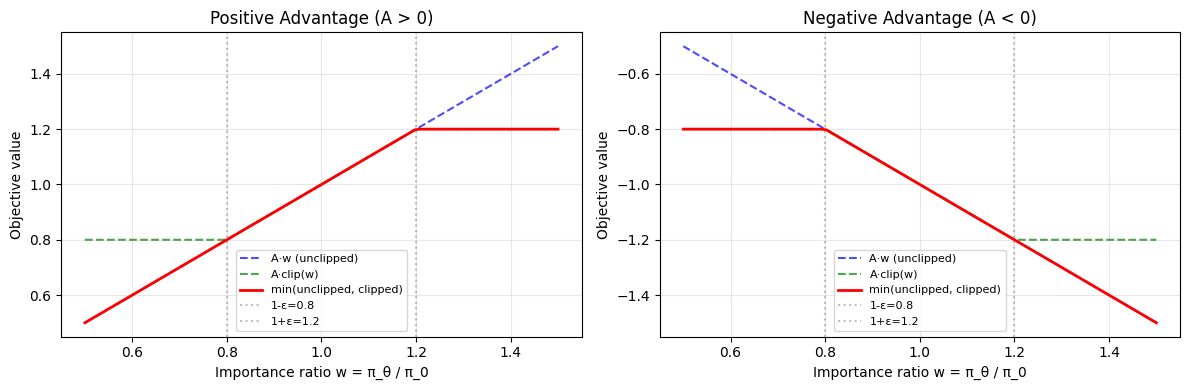

Key insight:
- Positive advantage: clip at 1+ε (don't over-upweight actions we already favor)
- Negative advantage: clip at 1-ε (don't over-downweight actions we already disfavor)
- When w is in [1-ε, 1+ε], clipping has no effect → gradient is the same as unclipped


In [18]:
# Visualize the PPO clipping objective
ratios = torch.linspace(0.5, 1.5, 100)
epsilon = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, A_sign, title in zip(axes, [1.0, -1.0], ['Positive Advantage (A > 0)', 'Negative Advantage (A < 0)']):
    A = A_sign
    unclipped = A * ratios
    clipped = A * ratios.clamp(1 - epsilon, 1 + epsilon)
    objective = torch.min(unclipped, clipped)
    
    ax.plot(ratios.numpy(), unclipped.numpy(), 'b--', label=f'A·w (unclipped)', alpha=0.7)
    ax.plot(ratios.numpy(), clipped.numpy(), 'g--', label=f'A·clip(w)', alpha=0.7)
    ax.plot(ratios.numpy(), objective.numpy(), 'r-', linewidth=2, label='min(unclipped, clipped)')
    ax.axvline(1 - epsilon, color='gray', linestyle=':', alpha=0.5, label=f'1-ε={1-epsilon}')
    ax.axvline(1 + epsilon, color='gray', linestyle=':', alpha=0.5, label=f'1+ε={1+epsilon}')
    ax.set_xlabel('Importance ratio w = π_θ / π_0')
    ax.set_ylabel('Objective value')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight:")
print("- Positive advantage: clip at 1+ε (don't over-upweight actions we already favor)")
print("- Negative advantage: clip at 1-ε (don't over-downweight actions we already disfavor)")
print("- When w is in [1-ε, 1+ε], clipping has no effect → gradient is the same as unclipped")

### 5.4 GSPO: Sequence-Level Geometric Mean Reweighting

GSPO (Group Sequence Policy Optimization) addresses the bias of token-level reweighting
by using the **geometric mean** of token-level importance weights as a sequence-level weight:

$$s^{(i,j)} = \left(\prod_{t=1}^{L} \frac{\pi_\theta(y_t | x, y_{<t})}{\pi_0(y_t | x, y_{<t})}\right)^{1/L} = \exp\left(\frac{1}{L} \sum_t \log \frac{\pi_\theta(y_t)}{\pi_0(y_t)}\right)$$

This is the $L$-th root of the full sequence-level importance weight, avoiding exponential blowup
while still using a single scalar per sequence (shared across all tokens).

In [19]:
# Compare importance weight scale: full product vs geometric mean
seq_lengths = [10, 50, 100, 200, 512]
per_token_log_ratio = 0.05  # small per-token drift from sampling policy

print("Sequence-level importance weight comparison (small per-token drift = 0.05 log-ratio):")
print(f"{'Length':>8} {'Full product w':>18} {'Geometric mean s':>20} {'Ratio w/s':>12}")
print("-" * 60)
for L in seq_lengths:
    full_product = torch.exp(torch.tensor(L * per_token_log_ratio)).item()
    geom_mean = torch.exp(torch.tensor(per_token_log_ratio)).item()  # exp(mean log_ratio)
    print(f"{L:>8} {full_product:>18.4f} {geom_mean:>20.4f} {full_product/geom_mean:>12.2f}")
print()
print("The geometric mean stays bounded regardless of sequence length.")
print("The full product grows exponentially → unusable for long sequences.")

Sequence-level importance weight comparison (small per-token drift = 0.05 log-ratio):
  Length     Full product w     Geometric mean s    Ratio w/s
------------------------------------------------------------
      10             1.6487               1.0513         1.57
      50            12.1825               1.0513        11.59
     100           148.4132               1.0513       141.17
     200         22026.4648               1.0513     20952.22
     512  131201531904.0000               1.0513 124802759515.51

The geometric mean stays bounded regardless of sequence length.
The full product grows exponentially → unusable for long sequences.


## 6. Running the Full Training Loop

The training script `cs336_alignment/train_grpo.py` implements the full loop. Here's how to run it:

In [20]:
# Example training commands (run in terminal, not notebook)
commands = {
    "Standard on-policy GRPO": """
python -m cs336_alignment.train_grpo \
    --model_id allenai/OLMo-2-0425-1B \
    --train_data data/gsm8k/train.jsonl \
    --val_data data/gsm8k/test.jsonl \
    --prompt r1_zero \
    --output_dir checkpoints/grpo_standard \
    --seed 42 --wandb
""",
    "Dr. GRPO (no std normalization, constant loss)": """
python -m cs336_alignment.train_grpo \
    --advantage_normalizer none \
    --loss_normalization constant \
    --normalization_constant 131072 \
    --output_dir checkpoints/dr_grpo
""",
    "RFT (Rejection Fine-Tuning)": """
python -m cs336_alignment.train_grpo \
    --baseline none \
    --advantage_normalizer none \
    --loss_normalization constant \
    --normalization_constant 131072 \
    --output_dir checkpoints/rft
""",
    "MaxRL": """
python -m cs336_alignment.train_grpo \
    --advantage_normalizer mean \
    --loss_normalization constant \
    --output_dir checkpoints/maxrl
""",
    "Off-policy with GRPO clipping (32x off-policy)": """
python -m cs336_alignment.train_grpo \
    --importance_reweighting grpo \
    --cliprange 0.2 \
    --off_policy_steps 32 \
    --rollout_batch_size 8 \
    --output_dir checkpoints/offpolicy_grpo
""",
    "Off-policy with GSPO clipping": """
python -m cs336_alignment.train_grpo \
    --importance_reweighting gspo \
    --cliprange 0.0003 \
    --off_policy_steps 32 \
    --rollout_batch_size 8 \
    --output_dir checkpoints/offpolicy_gspo
""",
}

for name, cmd in commands.items():
    print(f"# {name}")
    print(cmd)

# Standard on-policy GRPO

python -m cs336_alignment.train_grpo     --model_id allenai/OLMo-2-0425-1B     --train_data data/gsm8k/train.jsonl     --val_data data/gsm8k/test.jsonl     --prompt r1_zero     --output_dir checkpoints/grpo_standard     --seed 42 --wandb

# Dr. GRPO (no std normalization, constant loss)

python -m cs336_alignment.train_grpo     --advantage_normalizer none     --loss_normalization constant     --normalization_constant 131072     --output_dir checkpoints/dr_grpo

# RFT (Rejection Fine-Tuning)

python -m cs336_alignment.train_grpo     --baseline none     --advantage_normalizer none     --loss_normalization constant     --normalization_constant 131072     --output_dir checkpoints/rft

# MaxRL

python -m cs336_alignment.train_grpo     --advantage_normalizer mean     --loss_normalization constant     --output_dir checkpoints/maxrl

# Off-policy with GRPO clipping (32x off-policy)

python -m cs336_alignment.train_grpo     --importance_reweighting grpo     --cliprang

## 7. Interpreting Training Metrics

When training is running, you should monitor these metrics:

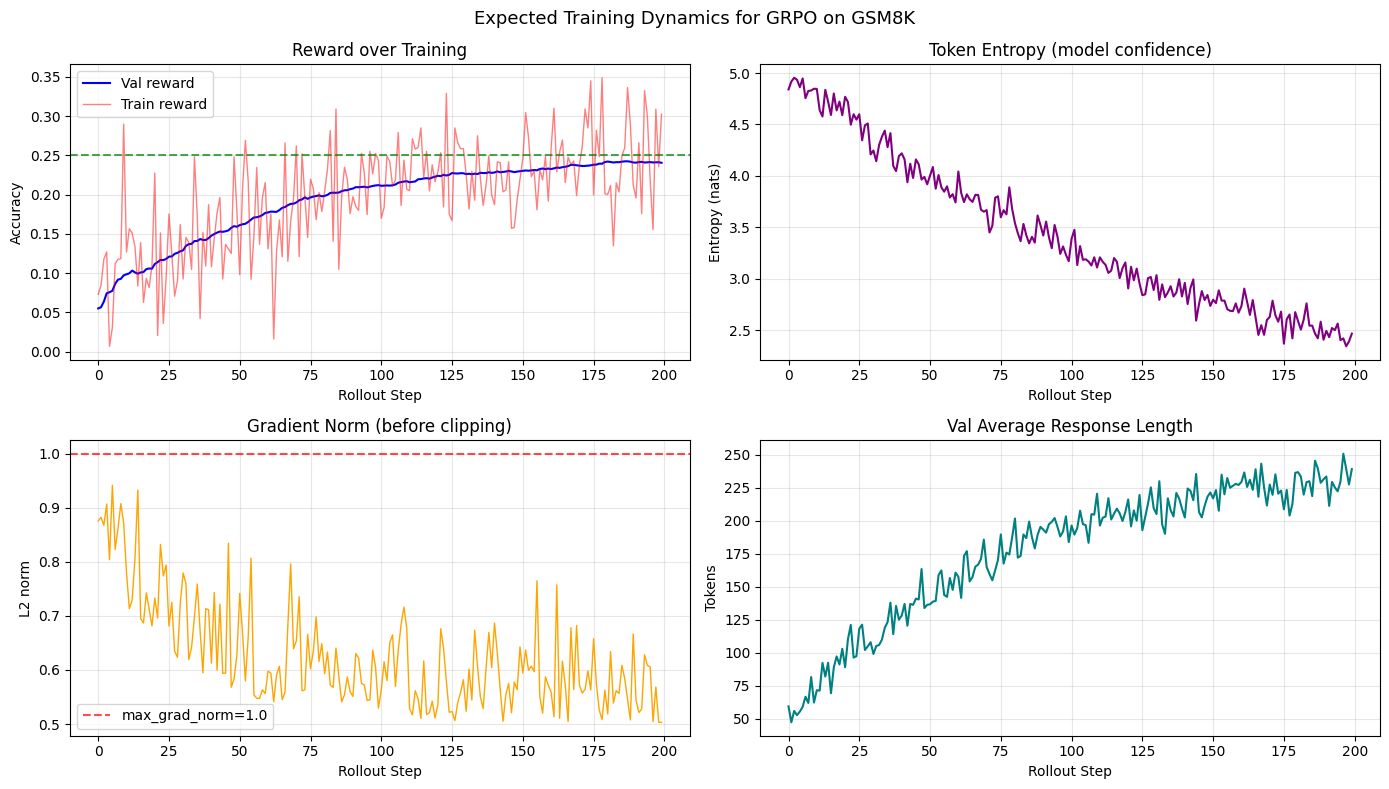

What to look for:
✓ Val reward should increase over training (target: ~25% final accuracy)
✓ Entropy should decrease (model becomes more confident in its answers)
✓ Grad norm should stay bounded after clipping
✓ Response length often increases as model learns to use chain-of-thought
✗ If reward stays at 0: check that rollouts have non-zero rewards at all
✗ If reward collapses after initial increase: learning rate may be too high


In [21]:
# Simulate expected training curves to illustrate what healthy training looks like
import numpy as np

np.random.seed(42)
n_steps = 200
t = np.arange(n_steps)

# Simulated metrics (approximate expected behavior)
val_reward = 0.05 + 0.20 * (1 - np.exp(-t / 50)) + 0.01 * np.random.randn(n_steps).cumsum() / np.sqrt(t + 1)
val_reward = np.clip(val_reward, 0, 1)
train_reward = val_reward + 0.05 * np.random.randn(n_steps)
train_reward = np.clip(train_reward, 0, 1)
entropy = 3.5 * np.exp(-t / 150) + 1.5 + 0.1 * np.random.randn(n_steps)
grad_norm = 0.5 + 0.3 * np.exp(-t / 30) + 0.1 * np.abs(np.random.randn(n_steps))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t, val_reward, 'b-', label='Val reward', linewidth=1.5)
axes[0, 0].plot(t, train_reward, 'r-', alpha=0.5, label='Train reward', linewidth=1)
axes[0, 0].set_title('Reward over Training')
axes[0, 0].set_xlabel('Rollout Step')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].axhline(0.25, color='green', linestyle='--', alpha=0.7, label='Target 25%')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t, entropy, 'purple', linewidth=1.5)
axes[0, 1].set_title('Token Entropy (model confidence)')
axes[0, 1].set_xlabel('Rollout Step')
axes[0, 1].set_ylabel('Entropy (nats)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t, grad_norm, 'orange', linewidth=1)
axes[1, 0].set_title('Gradient Norm (before clipping)')
axes[1, 0].set_xlabel('Rollout Step')
axes[1, 0].set_ylabel('L2 norm')
axes[1, 0].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='max_grad_norm=1.0')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Response length over time
avg_length = 50 + 200 * (1 - np.exp(-t / 80)) + 10 * np.random.randn(n_steps)
avg_length = np.clip(avg_length, 20, 512)
axes[1, 1].plot(t, avg_length, 'teal', linewidth=1.5)
axes[1, 1].set_title('Val Average Response Length')
axes[1, 1].set_xlabel('Rollout Step')
axes[1, 1].set_ylabel('Tokens')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Expected Training Dynamics for GRPO on GSM8K', fontsize=13)
plt.tight_layout()
plt.show()

print("What to look for:")
print("✓ Val reward should increase over training (target: ~25% final accuracy)")
print("✓ Entropy should decrease (model becomes more confident in its answers)")
print("✓ Grad norm should stay bounded after clipping")
print("✓ Response length often increases as model learns to use chain-of-thought")
print("✗ If reward stays at 0: check that rollouts have non-zero rewards at all")
print("✗ If reward collapses after initial increase: learning rate may be too high")

## 8. Summary: What Each Component Does

| Component | Role | Key Design Choice |
|-----------|------|------------------|
| `tokenize_prompt_and_output` | Create training inputs with response mask | Separate tokenization to preserve boundaries |
| `get_response_log_probs` | Score model outputs | Used in both loss computation and off-policy old_log_probs |
| `compute_rollout_rewards` | Apply reward function | Returns raw binary rewards (0 or 1 for GSM8K) |
| `compute_group_normalized_rewards` | Compute advantages | Group mean baseline + std normalization |
| `compute_policy_gradient_loss` | Per-token loss | Supports on-policy and 3 off-policy variants |
| `aggregate_loss_across_microbatch` | Scalar loss | Sequence vs constant normalization |
| `grpo_train_step` | Full training step | Gradient accumulation, grad norm clipping |

### GRPO Variants Compared

| Variant | Baseline | Normalizer | Loss Norm | Key Property |
|---------|----------|------------|-----------|-------------|
| GRPO-sequence | mean | std | sequence | Standard; each seq equal weight |
| GRPO-constant | mean | std | constant | More faithful gradient |
| Dr. GRPO | mean | none | constant | Correct expectation; higher variance |
| RFT | none | none | constant | Only trains on correct responses |
| MaxRL | mean | mean | constant | Upweights harder prompts |

### Off-Policy Methods

| Method | Reweighting | Clipping | Bias | Variance |
|--------|-------------|----------|------|----------|
| On-policy | none | — | Zero | High (1 step/batch) |
| Off-policy naive | none | — | High | Low |
| Off-policy noclip | token-level | none | Medium | Higher |
| Off-policy GRPO | token-level | PPO clip | Medium | Lower |
| Off-policy GSPO | sequence geometric mean | clip | Lower | Medium |

In [22]:
print("Files created for this assignment:")
import os
from pathlib import Path

base = Path(os.getcwd())
files = [
    ("cs336_alignment/grpo.py", "Core GRPO implementation (all required functions)"),
    ("cs336_alignment/checkpoint.py", "Model loading utilities"),
    ("cs336_alignment/prompting_baselines.py", "Prompting experiment scripts"),
    ("cs336_alignment/train_grpo.py", "Full GRPO training loop"),
    ("tests/adapters.py", "Test harness adapters (filled in)"),
    ("walkthrough.ipynb", "This notebook"),
]

for fname, desc in files:
    exists = (base / fname).exists() or (base.parent / fname).exists()
    status = "✓" if exists else "✗"
    print(f"  {status} {fname:<45} {desc}")

Files created for this assignment:
  ✓ cs336_alignment/grpo.py                       Core GRPO implementation (all required functions)
  ✓ cs336_alignment/checkpoint.py                 Model loading utilities
  ✓ cs336_alignment/prompting_baselines.py        Prompting experiment scripts
  ✓ cs336_alignment/train_grpo.py                 Full GRPO training loop
  ✓ tests/adapters.py                             Test harness adapters (filled in)
  ✓ walkthrough.ipynb                             This notebook
